In [ ]:
# ! pip install openai-agents
# ! pip install -Uq "openai-agents[litellm]"

In [ ]:
import os
import getpass
from agents import Agent, Runner, ModelSettings,trace
from agents.extensions.models.litellm_model import LitellmModel
from agents import Agent, function_tool, Runner
from pydantic import BaseModel
from pydantic import BaseModel, Field
from openai.types.responses import ResponseTextDeltaEvent
import asyncio
from agents.extensions.visualization import draw_graph

In [ ]:
model_id = 'huggingface/nscale/Qwen/Qwen3-8B'

In [ ]:
hf_model = LitellmModel(
    model=model_id,
    api_key=os.environ["HF_TOKEN"],
)

### Multi Agent Orchestration

In [ ]:
intro = """
You are a sales agent working for ComplAI,
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

In [ ]:
sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model=hf_model)
sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model=hf_model)
sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model=hf_model)

In [ ]:
result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)



**Subject:** Achieve SOC2 Compliance with AI-Powered Efficiency  

**Dear [First Name],**  

In an era where data security is non-negotiable, organizations face escalating pressure to meet stringent compliance standards like SOC2. Yet, the manual processes, fragmented documentation, and constant audits demand significant resources—resources many teams cannot afford to divert from their core missions.  

At ComplAI, we’ve engineered a **SaaS platform powered by AI** to transform how enterprises achieve and maintain SOC2 compliance. By automating repetitive tasks, streamlining documentation, and providing real-time risk assessments, our solution enables organizations to meet regulatory requirements with precision, speed, and confidence.  

**Why ComplAI?**  
- **AI-Driven Automation:** Eliminate manual data entry and audit preparation with intelligent workflows that adapt to your evolving needs.  
- **Proactive Compliance:** Identify and remediate risks before audits with predictive an

 to Fortune 500 enterprises—have achieved compliance **within 60 days** on average, with a 95% satisfaction rate in post-implementation reviews.  

**Let’s discuss how ComplAI can accelerate your compliance journey.**  
[Schedule a Free Demo] | [Request a Compliance Assessment]  

This is your opportunity to future-proof your operations, mitigate risks, and focus on growth.  

Sincerely,  
[Your Full Name]  
Head of Sales, ComplAI  
[Email Address] | [Phone Number] | [Website URL]  

*P.S. For a limited time, we’re offering [X] free compliance check for new clients. Let’s ensure you’re prepared before the next audit.*  

---  
*ComplAI: Empowering Organizations to Thrive in a Regulated World.*  

---  
**Note:** Customize bracketed fields and add a link to your scheduling tool or demo page.

In [ ]:
message = "Write a cold sales email"

with trace("Parallel cold emails"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )

outputs = [result.final_output for result in results]

for output in outputs:
    print(output + "\n\n")



**Subject:** Achieve SOC2 Compliance with AI-Powered Efficiency – Secure Your Business Now  

**Dear [First Name],**  

As a leader in your field, you understand the critical importance of maintaining robust compliance frameworks to protect your organization’s reputation, customer trust, and financial stability. Yet, traditional SOC2 compliance processes—manual documentation, error-prone audits, and escalating costs—often consume valuable time and resources, diverting focus from your core mission.  

At **ComplAI**, we’ve engineered an AI-powered SaaS platform designed to transform how organizations achieve and maintain SOC2 compliance. Our solution automates repetitive tasks, streamlines documentation, and delivers real-time insights to ensure your systems meet stringent compliance standards. Whether you’re preparing for a SOC2 audit or seeking to strengthen your controls, ComplAI empowers you to act with confidence, precision, and agility.  

**Why ComplAI?**  
- **Automated Compli

In [ ]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Do not give an explanation; reply with the selected email only.
"""

sales_picker = Agent(name="Sales_picker", instructions=decision, model=hf_model)

message = "Write a cold sales email"

with trace("Sales selection workflow"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    best = await Runner.run(sales_picker, emails)

    print(f"Best sales email:\n{best.final_output}")

Best sales email:


**Subject:** Audit-proof your business in 30 seconds? Let’s talk.  

---  

**Hey [First Name],**  

Ever felt like your SOC2 compliance is a never-ending maze of paperwork, panic, and *one too many* caffeine-fueled Google searches for “what is a SOC2 control” (we’ve been there, trust us)?  

We’re here to turn that chaos into a smooth, stress-free experience. Meet **ComplAI**—your AI-powered sidekick for SOC2 compliance and audit prep. Think of it as a magic wand for your compliance team, but instead of a wand, we’ve got [insert clever metaphor here, e.g., “a caffeine-free, 24/7 compliance unicorn”].  

**Here’s how it works:**  
✅ **AI-powered magic** to automate your SOC2 controls.  
✅ **Audit-ready reports** in seconds, not weeks.  
✅ **Zero stress**—because who has time for compliance nightmares?  

No more late-night spreadsheet edits or yelling at your IT team. We’ve got your back.  

**Hit reply** and we’ll send you a free 14-day trial—no credit card require

In [ ]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3]

tools

[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x78e365a2e390>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False, custom_data_extractor=None, allowed_callers=None, output_json_schema=None),
 FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input sch

In [ ]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.

2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.

"""

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=hf_model)



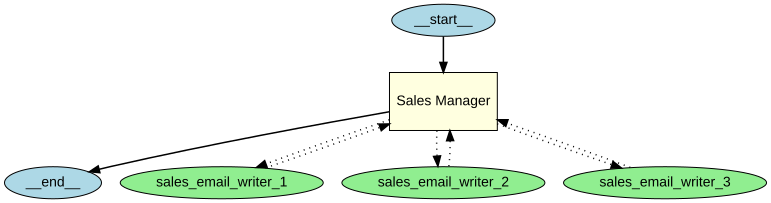

In [ ]:
draw_graph(sales_manager)

In [ ]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)
print(result.final_output)


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



APIError: litellm.APIError: HuggingfaceException - {"error":"You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage."}